# Percolation transitions in semantic space determine the granularity of AI risk taxonomies
## Reproducible analysis pipeline

This notebook reproduces the full analysis pipeline of the manuscript
*"Percolation transitions in semantic space determine the granularity of AI risk taxonomies"*.
It is designed to be read alongside the paper and the repository.

**Execution policy.** Light computations are executed live in this notebook. Heavy
computations (the 1,000-replicate threshold sweep, the 100-replicate
cohesion–attraction crossing, and the 28-step granularity flow) are **not** re-run by
default. For each of these, the exact reproduction code is shown in a cell guarded by
the global flag `RUN_FULL` (set to `False` below), and the archived artifact from
`data/experiments/review/` is loaded instead for all downstream analysis. Expected
runtimes for the full reproductions are noted in each section. With
`RUN_FULL = False` the notebook executes end-to-end in a few minutes.

### Data provenance

- **Master inventory** — 1,612 bilingual (English/Korean) risk cards, the output of the
  Stage-1 curation pipeline: `data/experiments/stage1/out/master.json`. Each card
  carries an identifier (`l4_id`), bilingual labels and definitions, and impact metadata.
- **Embeddings** — `data/experiments/stage1/out/emb_78d29c0cbe8d.npy`, a
  1,612 × 1,024 float32 matrix of sentence embeddings, row-aligned with the card list
  in `master.json`. Rows are unit-normalised (we re-normalise defensively below).
- **Archived experiment artifacts** — `data/experiments/review/` contains the
  outputs of the heavy experiments referenced throughout
  (`boot1000_agg.npz`, `cohdiv_all.npz`, `cohdiv_frac_*.npz`, `flow_states.json`,
  `flow4_state.json`, E5 encoder artifacts, and others).

In [1]:
import json, math, time, collections
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

RUN_FULL = False   # set True to re-run the heavy experiments (hours); see per-section notes

ROOT = '.'  # repository root (notebook lives in analysis/, executed with cwd=repo root or adjust)
import os
if not os.path.exists(os.path.join(ROOT, 'data')):
    ROOT = '..'  # notebook executed from analysis/
S1 = os.path.join(ROOT, 'data/experiments/stage1/out')
REV = os.path.join(ROOT, 'data/experiments/review')

master = json.load(open(os.path.join(S1, 'master.json')))
cards = master['cards']
ids = [c['l4_id'] for c in cards]
labels_en = [c['label_en'] for c in cards]
id2idx = {cid: i for i, cid in enumerate(ids)}
N = len(cards)
print(f'Master inventory: {N} cards (release {master.get("release_id", "?")})')

emb = np.load(os.path.join(S1, 'emb_78d29c0cbe8d.npy'))
X = emb / np.linalg.norm(emb, axis=1, keepdims=True)
print('Embedding matrix:', X.shape, X.dtype)
assert X.shape[0] == N

Master inventory: 1612 cards (release stage1-master)
Embedding matrix: (1612, 1024) float32


## 1. Similarity structure of the inventory

All analyses operate on the cosine-similarity matrix of the unit-normalised embeddings,
$S_{ij} = x_i \cdot x_j$. We first characterise the pairwise similarity distribution over
the $\binom{1612}{2} = 1{,}298{,}466$ unordered pairs. The paper reports a mean pairwise
similarity of **0.570** and a maximum of **0.94**; both are recomputed here. We also list
the ten most similar card pairs with their English labels, which illustrates the kind of
near-duplicate semantic structure that the percolation analysis quantifies.

Pairs: 1,298,466  mean = 0.570  sd = 0.061  max = 0.940


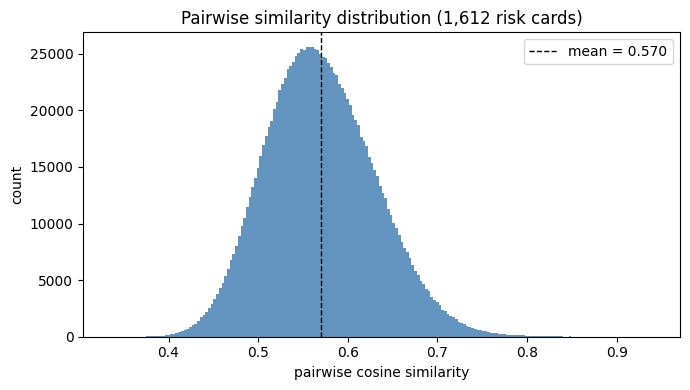

In [2]:
S = (X @ X.T).astype(np.float32)
iu = np.triu_indices(N, 1)
sims = S[iu]
print(f'Pairs: {len(sims):,}  mean = {sims.mean():.3f}  sd = {sims.std():.3f}  max = {sims.max():.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sims, bins=200, color='steelblue', alpha=0.85)
ax.axvline(sims.mean(), color='k', ls='--', lw=1, label=f'mean = {sims.mean():.3f}')
ax.set_xlabel('pairwise cosine similarity'); ax.set_ylabel('count')
ax.set_title('Pairwise similarity distribution (1,612 risk cards)')
ax.legend(); plt.tight_layout(); plt.show()

In [3]:
top = np.argsort(sims)[::-1][:10]
print('Top-10 most similar pairs:')
for r, k in enumerate(top, 1):
    i, j = iu[0][k], iu[1][k]
    print(f'{r:2d}. s = {sims[k]:.4f}  [{ids[i]}] {labels_en[i]}')
    print(f'{"":14s}[{ids[j]}] {labels_en[j]}')

Top-10 most similar pairs:
 1. s = 0.9404  [RAI4-0506] Ownership uncertainty for AI-generated content
              [RAI4-1368] Uncertain IP status of AI-generated content
 2. s = 0.9252  [RAI4-0551] Objective misalignment with human intent
              [RAI4-0591] Misalignment with human values
 3. s = 0.9231  [RAI4-1608] Reputational damage from use or misuse of AI systems
              [RAI4-1726] Reputational harm attributable to AI systems
 4. s = 0.9178  [RAI4-0523] Lack of system transparency
              [RAI4-0596] Lack of model transparency
 5. s = 0.9164  [RAI4-0228] Explicit hazard non-rejection
              [RAI4-0229] Implicit hazard non-rejection
 6. s = 0.9142  [RAI4-0682] Generation of content enabling nonviolent crimes
              [RAI4-0691] Generation of content enabling violent crimes
 7. s = 0.9079  [RAI4-1055] Compromising privacy by leaking sensitive information
              [RAI4-1072] Compromising privacy by leaking private information
 8. s = 0.9031  [R

## 2. Threshold-graph sweep and the two percolation transitions

For a threshold $\tau$, the threshold graph $G_\tau$ connects cards $i, j$ whenever
$S_{ij} \ge \tau$; its connected components are the clusters at resolution $\tau$. Rather
than rebuilding the graph at every $\tau$, we run a single **event-driven union–find**
pass over the edges sorted by similarity, recording summary statistics on a grid of
step 0.0005 from $\tau = 0.94$ down to $\tau = 0.50$:

1. pooled mean within-cluster similarity ("mean cohesion"),
2. the mean over clusters of the per-cluster **minimum** internal similarity,
3. the number of clusters, and
4. the sizes of the largest and second-largest clusters.

The two transitions are located with a change-point estimator: the midpoint of the
0.01-wide window (20 grid steps) over which each cohesion curve drops the most.
The single full-inventory pass below runs in seconds; the paper's uncertainty
estimates come from **1,000 replicates** on 80% subsamples, which we load from the
archived aggregate `boot1000_agg.npz` (guarded reproduction below, ≈ 3 h).

In [4]:
TAUS = np.round(np.arange(0.9400, 0.49999, -0.0005), 4)
T = len(TAUS)

def sweep(Ssub, taus=TAUS):
    '''Event-driven union-find sweep; returns (len(taus), 5) array:
    [pooled mean cohesion, mean per-cluster min, n clusters, largest, 2nd largest].'''
    n = Ssub.shape[0]
    iu2 = np.triu_indices(n, 1)
    sims2 = Ssub[iu2]
    o = np.argsort(sims2)[::-1]
    ei, ej, es = iu2[0][o], iu2[1][o], sims2[o]
    parent = np.arange(n); size = np.ones(n, int)
    members = {i: [i] for i in range(n)}
    cmin = {}; wsum = 0.0; wcnt = 0; msum = 0.0; mcnt = 0; ncl = n
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    out = np.empty((len(taus), 5), np.float32)
    e = 0; E = len(es); top2 = [1, 0]
    for ti, t in enumerate(taus):
        while e < E and es[e] >= t:
            a, b = find(ei[e]), find(ej[e])
            if a != b:
                ma, mb = members[a], members[b]
                blk = Ssub[np.ix_(ma, mb)]
                wsum += float(blk.sum()); wcnt += len(ma) * len(mb)
                bm = float(blk.min()); oa = cmin.get(a); ob = cmin.get(b)
                nm = bm
                if oa is not None: nm = min(nm, oa); msum -= oa; mcnt -= 1
                if ob is not None: nm = min(nm, ob); msum -= ob; mcnt -= 1
                if size[a] < size[b]: a, b = b, a; ma, mb = mb, ma
                parent[b] = a; size[a] += size[b]; members[a] = ma + mb; del members[b]
                cmin.pop(b, None); cmin[a] = nm; msum += nm; mcnt += 1
                ncl -= 1
            e += 1
        if ti % 4 == 0 or ti == len(taus) - 1:
            ss = sorted((size[r] for r in members), reverse=True)
            top2 = [ss[0], ss[1] if len(ss) > 1 else 0]
        out[ti] = [wsum / wcnt if wcnt else np.nan,
                   msum / mcnt if mcnt else np.nan, ncl, top2[0], top2[1]]
    return out

t0 = time.time()
full = sweep(S)
print(f'Single full-inventory sweep: {time.time() - t0:.1f} s over {T} grid points')

Single full-inventory sweep: 1.5 s over 881 grid points


Single-pass change points: tau1 = 0.8150 (mean cohesion), tau2 = 0.6965 (per-cluster minimum)


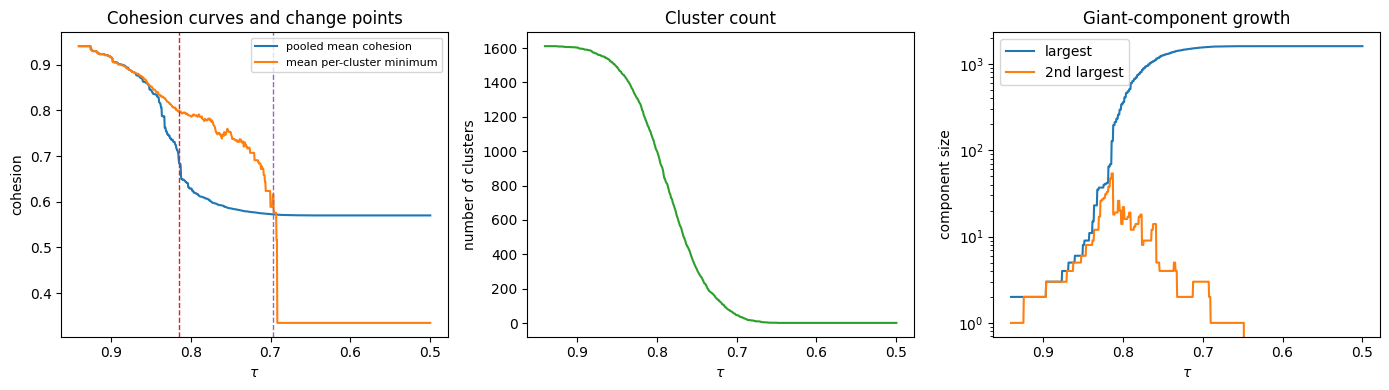

In [5]:
w = 20  # 0.01-wide change-point window
def changepoint(curve, taus=TAUS, w=w):
    d = np.abs(curve[:-w] - curve[w:])
    return taus[w:][np.nanargmax(d)] + 0.005  # window midpoint

t1_single = changepoint(full[:, 0])   # mean-cohesion transition
t2_single = changepoint(full[:, 1])   # min-cohesion transition
print(f'Single-pass change points: tau1 = {t1_single:.4f} (mean cohesion), '
      f'tau2 = {t2_single:.4f} (per-cluster minimum)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(TAUS, full[:, 0], label='pooled mean cohesion')
axes[0].plot(TAUS, full[:, 1], label='mean per-cluster minimum')
for tt, c in [(t1_single, 'tab:red'), (t2_single, 'tab:purple')]:
    axes[0].axvline(tt, color=c, ls='--', lw=1)
axes[0].set_xlabel(r'$\tau$'); axes[0].set_ylabel('cohesion'); axes[0].legend(fontsize=8)
axes[0].set_title('Cohesion curves and change points')
axes[1].plot(TAUS, full[:, 2], color='tab:green')
axes[1].set_xlabel(r'$\tau$'); axes[1].set_ylabel('number of clusters')
axes[1].set_title('Cluster count')
axes[2].plot(TAUS, full[:, 3], label='largest')
axes[2].plot(TAUS, full[:, 4], label='2nd largest')
axes[2].set_yscale('log'); axes[2].set_xlabel(r'$\tau$'); axes[2].set_ylabel('component size')
axes[2].set_title('Giant-component growth'); axes[2].legend()
for ax in axes: ax.invert_xaxis()
plt.tight_layout(); plt.show()

### Guarded full reproduction (1,000 replicates, ≈ 3 hours)

The archived 1,000-replicate sweep was produced by `analysis/boot1000_sweep.py`
(80% subsamples without replacement, seeds drawn from a fixed generator, chunked
across processes). The cell below shows the exact invocation; it is skipped unless
`RUN_FULL = True`.

In [6]:
if RUN_FULL:
    # Reproduces boot1000_c*.npz chunks; aggregate afterwards as in boot1000_agg.npz.
    # Expected runtime: ~3 hours on a single machine (run chunks in parallel to shorten).
    import subprocess
    for start, n, suf in [(0, 143, 'c0'), (143, 143, 'c1'), (286, 143, 'c2'),
                          (429, 143, 'c3'), (572, 143, 'c4'), (715, 143, 'c5'), (858, 142, 'c6')]:
        subprocess.run(['python3', 'analysis/boot1000_sweep.py', str(start), str(n), suf],
                       cwd=ROOT, check=True)
else:
    print('RUN_FULL is False - loading archived 1,000-replicate aggregate instead.')

RUN_FULL is False - loading archived 1,000-replicate aggregate instead.


Replicates: 1000
tau1 = 0.818 +/- 0.010   (paper: 0.818 +/- 0.010)
tau2 = 0.690 +/- 0.009   (paper: 0.690 +/- 0.009)


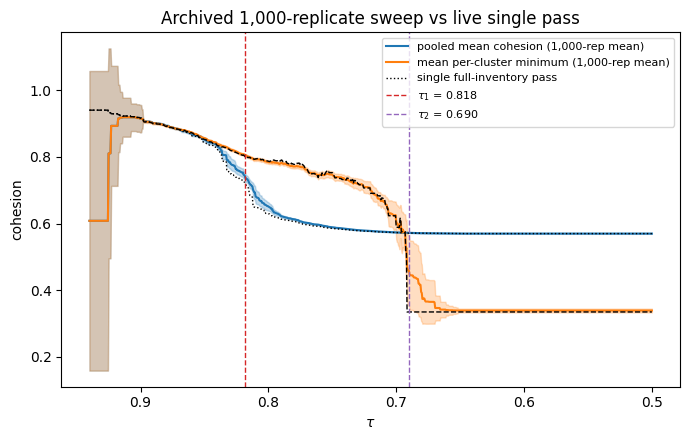

In [7]:
agg = np.load(os.path.join(REV, 'boot1000_agg.npz'))
taus_b, mean_b, sd_b = agg['taus'], agg['mean'], agg['sd']
t1s, t2s = agg['t1s'], agg['t2s']
print(f'Replicates: {int(agg["cnt"])}')
print(f'tau1 = {t1s.mean():.3f} +/- {t1s.std():.3f}   (paper: 0.818 +/- 0.010)')
print(f'tau2 = {t2s.mean():.3f} +/- {t2s.std():.3f}   (paper: 0.690 +/- 0.009)')

fig, ax = plt.subplots(figsize=(7, 4.5))
for k, (name, c) in enumerate([('pooled mean cohesion', 'tab:blue'),
                               ('mean per-cluster minimum', 'tab:orange')]):
    ax.plot(taus_b, mean_b[:, k], color=c, label=f'{name} (1,000-rep mean)')
    ax.fill_between(taus_b, mean_b[:, k] - sd_b[:, k], mean_b[:, k] + sd_b[:, k],
                    color=c, alpha=0.25)
ax.plot(TAUS, full[:, 0], 'k:', lw=1, label='single full-inventory pass')
ax.plot(TAUS, full[:, 1], 'k--', lw=1)
ax.axvline(t1s.mean(), color='tab:red', ls='--', lw=1, label=fr'$\tau_1$ = {t1s.mean():.3f}')
ax.axvline(t2s.mean(), color='tab:purple', ls='--', lw=1, label=fr'$\tau_2$ = {t2s.mean():.3f}')
ax.invert_xaxis(); ax.set_xlabel(r'$\tau$'); ax.set_ylabel('cohesion')
ax.set_title('Archived 1,000-replicate sweep vs live single pass')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. Random-merge null models

To confirm that the cohesion drops reflect semantic structure rather than the mechanics
of agglomeration, we compare the observed statistics against **random-merge nulls**: we
perform the *same number of merges* as the threshold graph at $\tau = 0.80$ (just below
$\tau_1$) and $\tau = 0.70$ (near $\tau_2$), but with uniformly random pairs of clusters,
and recompute (i) the pooled mean cohesion (mean-statistic null) and (ii) the mean
per-cluster minimum (min-statistic null).

For speed we use **20 random seeds** here; the paper uses **100**. The separation
between observed and null values is many null standard deviations, so the reduced
seed count does not affect the conclusion.

In [8]:
N_SEEDS = 20  # paper: 100

def observed_at(tau):
    ti = int(np.argmin(np.abs(TAUS - tau)))
    n_cl = int(full[ti, 2])
    return N - n_cl, full[ti, 0], full[ti, 1]  # merges, mean stat, min stat

def random_merge_null(n_merges, seed):
    rng = np.random.default_rng(seed)
    parent = np.arange(N); size = np.ones(N, int)
    members = {i: [i] for i in range(N)}
    cmin = {}; wsum = 0.0; wcnt = 0; msum = 0.0; mcnt = 0
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    roots = list(members)
    done = 0
    while done < n_merges:
        a, b = rng.choice(roots, 2, replace=False)
        a, b = find(a), find(b)
        if a == b:
            roots = list(members); continue
        ma, mb = members[a], members[b]
        blk = S[np.ix_(ma, mb)]
        wsum += float(blk.sum()); wcnt += len(ma) * len(mb)
        bm = float(blk.min()); oa = cmin.get(a); ob = cmin.get(b)
        nm = bm
        if oa is not None: nm = min(nm, oa); msum -= oa; mcnt -= 1
        if ob is not None: nm = min(nm, ob); msum -= ob; mcnt -= 1
        if size[a] < size[b]: a, b = b, a; ma, mb = mb, ma
        parent[b] = a; size[a] += size[b]; members[a] = ma + mb; del members[b]
        cmin.pop(b, None); cmin[a] = nm; msum += nm; mcnt += 1
        roots = list(members); done += 1
    return wsum / wcnt, msum / mcnt

for tau in (0.80, 0.70):
    n_m, obs_mean, obs_min = observed_at(tau)
    nulls = np.array([random_merge_null(n_m, s) for s in range(N_SEEDS)])
    zm = (obs_mean - nulls[:, 0].mean()) / nulls[:, 0].std()
    zn = (obs_min - nulls[:, 1].mean()) / nulls[:, 1].std()
    print(f'tau = {tau:.2f}  ({n_m} merges, {N_SEEDS} seeds)')
    print(f'  mean statistic: observed {obs_mean:.3f}  null {nulls[:,0].mean():.3f} '
          f'+/- {nulls[:,0].std():.3f}  (z = {zm:+.1f})')
    print(f'  min  statistic: observed {obs_min:.3f}  null {nulls[:,1].mean():.3f} '
          f'+/- {nulls[:,1].std():.3f}  (z = {zn:+.1f})')

tau = 0.80  (609 merges, 20 seeds)
  mean statistic: observed 0.629  null 0.569 +/- 0.002  (z = +37.5)
  min  statistic: observed 0.787  null 0.549 +/- 0.003  (z = +87.8)


tau = 0.70  (1566 merges, 20 seeds)
  mean statistic: observed 0.573  null 0.570 +/- 0.001  (z = +3.0)
  min  statistic: observed 0.589  null 0.432 +/- 0.005  (z = +32.9)


## 4. Cohesion–attraction crossing

The operational resolution $\tau^*$ is defined as the threshold at which cluster
**cohesion** stops dominating cross-cluster **attraction**:

- $\Phi_{\mathrm{coh}}(\tau)$ — the pooled mean within-cluster similarity of the
  threshold-graph partition at $\tau$ (as in Section 2);
- $\Phi_{\mathrm{att}}(\tau)$ — the mean over clusters of each cluster's **maximum
  external similarity** (the strongest similarity from any member to any card outside
  the cluster);
- $\tau^*$ — the first grid point (scanning from high to low $\tau$) at which
  $\Phi_{\mathrm{coh}} \le \Phi_{\mathrm{att}}$.

Below we compute the full-inventory crossing live on a **0.001 grid with exact
per-grid attraction** (a few seconds with the event-driven sweep). The paper's
uncertainty comes from **100 replicates** on 80% subsamples on a 0.0001 grid with a
$K$-nearest-neighbour attraction approximation (`analysis/coh_div_sweep.py`,
guarded below); its archive `cohdiv_all.npz` reports a crossing of
**0.828 ± 0.004** across replicates and **0.833** for the full inventory
(the finer 0.0001 grid resolves the crossing slightly above our 0.001-grid value).

In [9]:
t0 = time.time()
taus_x = np.round(np.arange(0.940, 0.789, -0.001), 4)
o = np.argsort(sims)[::-1]
ei, ej, es = iu[0][o], iu[1][o], sims[o]
parent = np.arange(N); size = np.ones(N, int)
members = {i: [i] for i in range(N)}
wsum = 0.0; wcnt = 0; e = 0; E = len(es)
def find(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]; a = parent[a]
    return a
Sd = S.copy(); np.fill_diagonal(Sd, -1.0)
curve = []; cross_live = None
for t in taus_x:
    while e < E and es[e] >= t:
        a, b = find(ei[e]), find(ej[e])
        if a != b:
            ma, mb = members[a], members[b]
            blk = S[np.ix_(ma, mb)]
            wsum += float(blk.sum()); wcnt += len(ma) * len(mb)
            if size[a] < size[b]: a, b = b, a; ma, mb = mb, ma
            parent[b] = a; size[a] += size[b]; members[a] = ma + mb; del members[b]
        e += 1
    if wcnt == 0:
        curve.append((t, np.nan, np.nan)); continue
    coh = wsum / wcnt
    # exact attraction: per-cluster maximum external similarity
    att_vals = []
    for r, mm in members.items():
        mask = np.ones(N, bool); mask[mm] = False
        att_vals.append(float(Sd[mm][:, mask].max()))
    att = float(np.mean(att_vals))
    curve.append((t, coh, att))
    if cross_live is None and coh <= att:
        cross_live = t
curve = np.array(curve)
print(f'Live full-inventory crossing (0.001 grid, exact attraction): '
      f'tau* = {cross_live:.3f}   [{time.time() - t0:.1f} s]')

Live full-inventory crossing (0.001 grid, exact attraction): tau* = 0.832   [2.7 s]


Archived 100-replicate crossing: 0.828 +/- 0.004 (paper: 0.828 +/- 0.004); archived full-inventory value: 0.833


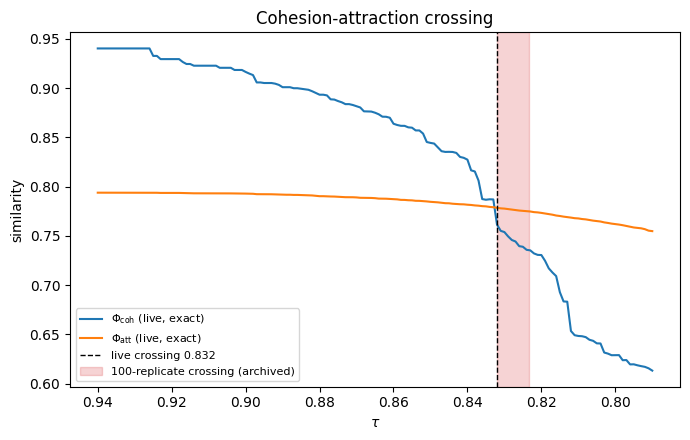

RUN_FULL is False - archived cohdiv_all.npz used above.


In [10]:
cd_all = np.load(os.path.join(REV, 'cohdiv_all.npz'))
cross_reps = cd_all['cross']; cross_reps = cross_reps[~np.isnan(cross_reps)]
print(f'Archived 100-replicate crossing: {cross_reps.mean():.3f} +/- {cross_reps.std():.3f} '
      f'(paper: 0.828 +/- 0.004); archived full-inventory value: 0.833')

fig, ax = plt.subplots(figsize=(7, 4.5))
ok = ~np.isnan(curve[:, 1])
ax.plot(curve[ok, 0], curve[ok, 1], label=r'$\Phi_{\mathrm{coh}}$ (live, exact)')
ax.plot(curve[ok, 0], curve[ok, 2], label=r'$\Phi_{\mathrm{att}}$ (live, exact)')
ax.axvline(cross_live, color='k', ls='--', lw=1, label=fr'live crossing {cross_live:.3f}')
ax.axvspan(cross_reps.mean() - cross_reps.std(), cross_reps.mean() + cross_reps.std(),
           color='tab:red', alpha=0.2, label='100-replicate crossing (archived)')
ax.invert_xaxis(); ax.set_xlabel(r'$\tau$'); ax.set_ylabel('similarity')
ax.set_title('Cohesion-attraction crossing'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

if RUN_FULL:
    # 100 replicates, 0.0001 grid, K-NN attraction checkpoints (hours; chunkable):
    import subprocess
    subprocess.run(['python3', 'analysis/coh_div_sweep.py', '0', '100', 'all'],
                   cwd=ROOT, check=True)
else:
    print('RUN_FULL is False - archived cohdiv_all.npz used above.')

## 5. Density dependence of the operational resolution

The crossing $\tau^*$ depends on how densely the semantic space is populated: with more
cards, clusters have stronger external neighbours and cohesion is overtaken earlier
(at higher $\tau$). We recompute $\tau^*(n)$ from the archived fractional-subsample
sweeps `cohdiv_frac_*.npz` (fractions 0.25–1.0 of the inventory, 20 replicates each) by
locating the sign change of $\Phi_{\mathrm{coh}} - \Phi_{\mathrm{att}}$ per replicate,
and fit the log-linear law reported in the paper,
$\tau^*(n) \approx 0.576 + 0.035 \ln n$.

n =   403  tau* = 0.7855 +/- 0.0083  (20 replicates)
n =   645  tau* = 0.8018 +/- 0.0062  (20 replicates)
n =   806  tau* = 0.8113 +/- 0.0076  (20 replicates)
n =   967  tau* = 0.8160 +/- 0.0072  (20 replicates)
n =  1128  tau* = 0.8226 +/- 0.0057  (20 replicates)
n =  1290  tau* = 0.8279 +/- 0.0031  (20 replicates)
n =  1451  tau* = 0.8303 +/- 0.0027  (20 replicates)
n =  1612  tau* = 0.8334 +/- 0.0000  (1 replicates)

Log-linear fit: tau* = 0.576 + 0.035 ln n   (paper: 0.576 + 0.035 ln n)


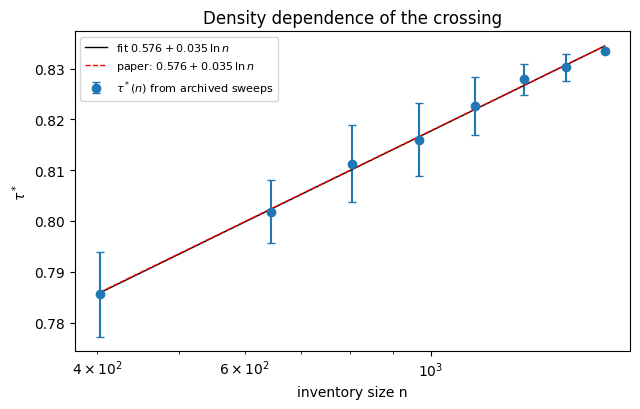

In [11]:
import glob

def crossings(taus, Cm, Sm):
    out = []
    for c, s in zip(Cm, Sm):
        ok = ~np.isnan(c) & ~np.isnan(s)
        t = taus[ok]; g = c[ok] - s[ok]
        x = np.nan
        for k in range(len(g) - 1):
            if g[k] > 0 and g[k + 1] <= 0:
                x = t[k] + (t[k + 1] - t[k]) * (g[k] / (g[k] - g[k + 1]))
                break
        out.append(x)
    return np.array(out)

rows = []
for f in sorted(glob.glob(os.path.join(REV, 'cohdiv_frac_*.npz'))):
    d = np.load(f)
    cr = crossings(d['taus'], d['C'], d['S'])
    cr = cr[~np.isnan(cr)]
    n = int(d['ns'][0])
    rows.append((n, cr.mean(), cr.std(), len(cr)))
rows.sort()
ns = np.array([r[0] for r in rows]); ts = np.array([r[1] for r in rows])
tsd = np.array([r[2] for r in rows])
for n, m, s, k in rows:
    print(f'n = {n:5d}  tau* = {m:.4f} +/- {s:.4f}  ({k} replicates)')

b, a = np.polyfit(np.log(ns), ts, 1)
print(f'\nLog-linear fit: tau* = {a:.3f} + {b:.3f} ln n   (paper: 0.576 + 0.035 ln n)')

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(ns, ts, yerr=tsd, fmt='o', capsize=3, label=r'$\tau^*(n)$ from archived sweeps')
xx = np.linspace(ns.min(), ns.max(), 200)
ax.plot(xx, a + b * np.log(xx), 'k-', lw=1, label=fr'fit ${a:.3f} + {b:.3f}\,\ln n$')
ax.plot(xx, 0.576 + 0.035 * np.log(xx), 'r--', lw=1, label=r'paper: $0.576 + 0.035\,\ln n$')
ax.set_xscale('log'); ax.set_xlabel('inventory size n'); ax.set_ylabel(r'$\tau^*$')
ax.set_title('Density dependence of the crossing'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. The granularity flow

Iterating the crossing construction defines the **granularity flow**: at each step, the
crossing $\tau^*$ of the current inventory is computed on a 0.0001 grid (with exact
per-cluster attraction), the connected components at $\tau^*$ are merged into single
cards (medoid representatives), and the procedure repeats on the reduced inventory.
The canonical 28-step trajectory was produced by `analysis/flow_canonical.py`
(resumable; ≈ hours in total) and is archived in
`data/experiments/review/flow_states.json`. We load it here.

**Validity rule.** A step is deemed valid when at least 90% of its merge groups have a
minimum internal similarity exceeding the size-matched random null by more than
2 standard deviations (`frac2` $\ge 0.90$). We show that this rule **first fails at
step 15**, and report per-step binomial $p$-values: with $k$ of $g$ groups exceeding the
$2\sigma$ bar, we test $k \sim \mathrm{Bin}(g, p_0)$ with $p_0 = P(Z > 2) \approx 0.023$
against the one-sided alternative that groups beat chance.

The first four steps define the tiers **F1–F4**: state 1 holds **1,383** cards and
state 4 holds **901** cards. Finally, we contrast the flow's F4 with a **single-pass**
threshold graph at F4's last crossing, $\tau = 0.7753$: applied directly to the master
inventory, this threshold yields **632 clusters with a giant component of 868 cards** —
the iterated flow avoids this collapse.

In [12]:
flow = json.load(open(os.path.join(REV, 'flow_states.json')))
steps = flow['steps']
print(f'Flow steps archived: {len(steps)}')
tau_t = [s['tau'] for s in steps]; n_after = [s['n_after'] for s in steps]
groups = [s['groups'] for s in steps]; frac2 = [s['frac2'] for s in steps]
med_z = [s['med_z'] for s in steps]

first_fail = next(k for k, s in enumerate(steps, 1) if s['frac2'] < 0.90)
print(f'Validity rule frac2 >= 0.90 first fails at step {first_fail} '
      f'(frac2 = {steps[first_fail-1]["frac2"]:.3f})')

p0 = 1 - stats.norm.cdf(2)  # ~0.0228
print('\nstep  tau*     n_after  groups  frac>2sd  med_z  binomial p')
for k, s in enumerate(steps, 1):
    g = s['groups']; kk = int(round(s['frac2'] * g))
    p = stats.binomtest(kk, g, p0, alternative='greater').pvalue
    flag = '' if s['frac2'] >= 0.90 else '  <-- fails validity rule'
    print(f'{k:4d}  {s["tau"]:.4f}  {s["n_after"]:6d}  {g:5d}   {s["frac2"]:.3f}   '
          f'{s["med_z"]:5.2f}  {p:9.2e}{flag}')

Flow steps archived: 28
Validity rule frac2 >= 0.90 first fails at step 15 (frac2 = 0.893)

step  tau*     n_after  groups  frac>2sd  med_z  binomial p
   1  0.8329    1383    109   1.000    3.98  8.15e-180
   2  0.8033    1154    121   1.000    3.79  1.57e-199
   3  0.7903    1038     81   1.000    4.30  8.24e-134
   4  0.7753     901     82   1.000    3.27  1.87e-135
   5  0.7634     792     70   1.000    3.64  9.75e-116
   6  0.7520     698     63   1.000    4.25  3.09e-104
   7  0.7455     641     42   0.976    4.22   1.78e-66
   8  0.7378     565     53   1.000    3.87   8.32e-88
   9  0.7305     491     52   1.000    3.43   3.66e-86
  10  0.7224     436     39   0.974    3.71   1.40e-61
  11  0.7157     382     37   0.919    2.92   9.97e-53
  12  0.7043     311     51   0.941    3.67   2.66e-75
  13  0.6987     274     26   1.000    3.00   1.91e-43
  14  0.6937     254     14   0.929    3.84   5.99e-21
  15  0.6856     218     28   0.893    2.68   2.58e-38  <-- fails validity rul

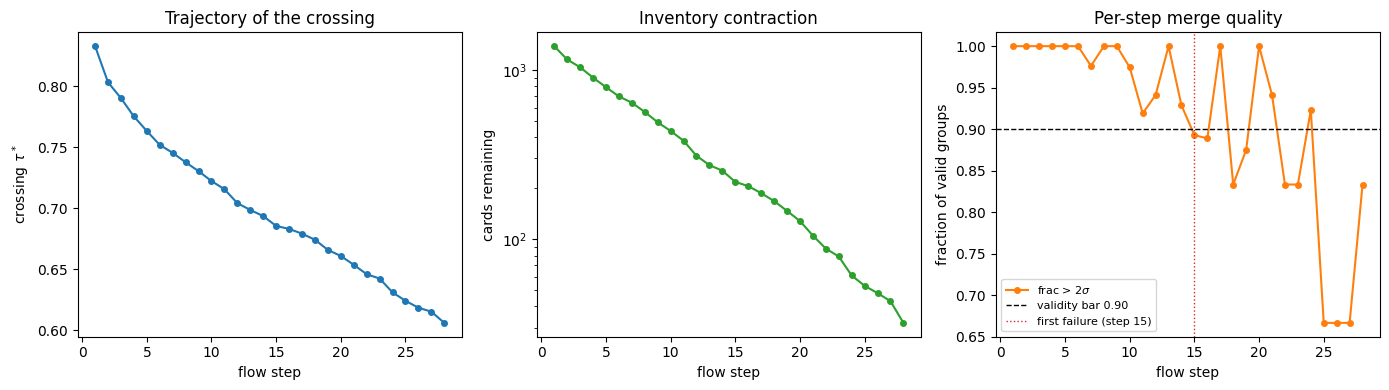

F1 (state 1): 1383 cards   F4 (state 4): 901 cards


In [13]:
ks = np.arange(1, len(steps) + 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(ks, tau_t, 'o-', ms=4)
axes[0].set_xlabel('flow step'); axes[0].set_ylabel(r'crossing $\tau^*$')
axes[0].set_title('Trajectory of the crossing')
axes[1].plot(ks, n_after, 'o-', ms=4, color='tab:green')
axes[1].set_yscale('log'); axes[1].set_xlabel('flow step'); axes[1].set_ylabel('cards remaining')
axes[1].set_title('Inventory contraction')
axes[2].plot(ks, frac2, 'o-', ms=4, color='tab:orange', label=r'frac > 2$\sigma$')
axes[2].axhline(0.90, color='k', ls='--', lw=1, label='validity bar 0.90')
axes[2].axvline(first_fail, color='tab:red', ls=':', lw=1, label=f'first failure (step {first_fail})')
axes[2].set_xlabel('flow step'); axes[2].set_ylabel('fraction of valid groups')
axes[2].set_title('Per-step merge quality'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'F1 (state 1): {steps[0]["n_after"]} cards   F4 (state 4): {steps[3]["n_after"]} cards')

In [14]:
# Single-pass contrast: threshold graph at F4's last crossing tau = 0.7753 on the master inventory
tau_c = 0.7753
parent = np.arange(N)
def find(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]; a = parent[a]
    return a
for a, b in zip(iu[0][sims >= tau_c], iu[1][sims >= tau_c]):
    ra, rb = find(a), find(b)
    if ra != rb: parent[rb] = ra
roots = np.array([find(i) for i in range(N)])
_, cnts = np.unique(roots, return_counts=True)
print(f'Single pass at tau = {tau_c}: {len(cnts)} clusters, giant component = {cnts.max()} cards')
print(f'Flow F4 at the same terminal threshold: {steps[3]["n_after"]} cards, largest group '
      f'far below the giant component - the iterated flow prevents percolative collapse.')

if RUN_FULL:
    # Full 28-step flow reproduction (resumable; delete/move flow_states.json first).
    # Expected runtime: several hours in total.
    import subprocess
    subprocess.run(['python3', 'analysis/flow_canonical.py'], cwd=ROOT, check=True)
else:
    print('RUN_FULL is False - archived flow_states.json used above.')

Single pass at tau = 0.7753: 632 clusters, giant component = 868 cards
Flow F4 at the same terminal threshold: 901 cards, largest group far below the giant component - the iterated flow prevents percolative collapse.
RUN_FULL is False - archived flow_states.json used above.


## 7. Anatomy of the F4 tier

The F4 state (`flow4_state.json`) holds **901 cards**, of which **211** are multi-card
groups (the remainder are singletons carried through unchanged). We examine the group
size distribution and, for every multi-card group, the **minimum within-group cosine**
as a function of group size, against a **size-matched random null**: for each size $s$
we draw 50 random $s$-card subsets of the master inventory and record the minimum
pairwise cosine. Groups sit far above the null, confirming semantic coherence — even
though **91 of the 211** multi-card groups have a minimum internal similarity below the
terminal crossing $\tau^*_4 = 0.7753$ (internal cohesion is a set property, not an
edge-threshold property).

F4 crossing sequence tau*_1..4: [0.8329, 0.8033, 0.7903, 0.7753]
F4: 901 cards, 211 multi-card groups, 690 singletons, largest group = 56
Groups with min within-group cosine below tau*_4 = 0.7753: 91/211


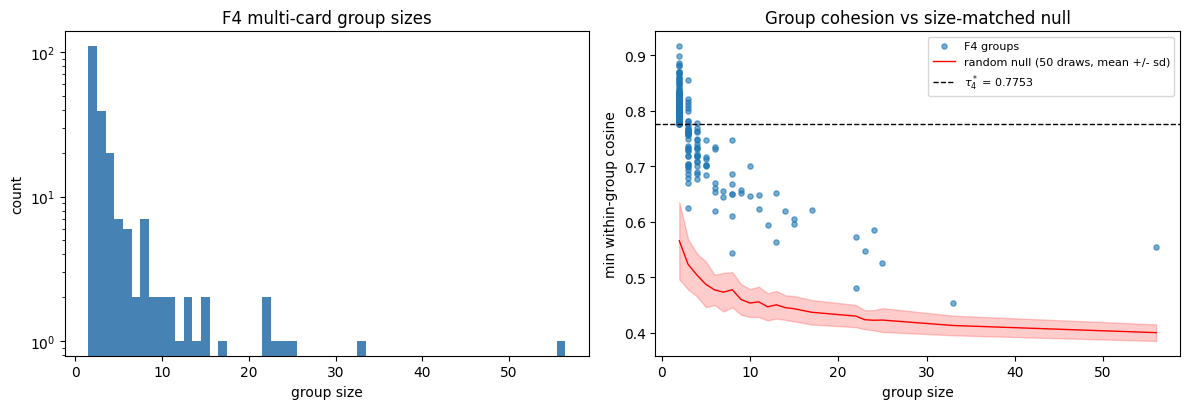

In [15]:
f4 = json.load(open(os.path.join(REV, 'flow4_state.json')))
print('F4 crossing sequence tau*_1..4:', f4['taus'])
f4cards = f4['cards']
sizes = np.array([c['n'] for c in f4cards])
multi = [c for c in f4cards if c['n'] > 1]
print(f'F4: {len(f4cards)} cards, {len(multi)} multi-card groups, '
      f'{(sizes == 1).sum()} singletons, largest group = {sizes.max()}')

tau4 = f4['taus'][-1]
below = sum(1 for c in multi if c['min_cos'] < tau4)
print(f'Groups with min within-group cosine below tau*_4 = {tau4}: {below}/{len(multi)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(sizes[sizes > 1], bins=np.arange(1.5, sizes.max() + 1.5), color='steelblue')
axes[0].set_yscale('log'); axes[0].set_xlabel('group size'); axes[0].set_ylabel('count')
axes[0].set_title('F4 multi-card group sizes')

rng = np.random.default_rng(7)
uniq_sizes = np.unique(sizes[sizes > 1])
null_mean, null_lo, null_hi = [], [], []
for s in uniq_sizes:
    vals = []
    for _ in range(50):
        idx = rng.choice(N, s, replace=False)
        sub = S[np.ix_(idx, idx)]
        vals.append(sub[np.triu_indices(s, 1)].min())
    vals = np.array(vals)
    null_mean.append(vals.mean()); null_lo.append(vals.mean() - vals.std()); null_hi.append(vals.mean() + vals.std())

axes[1].scatter([c['n'] for c in multi], [c['min_cos'] for c in multi],
                s=14, alpha=0.6, label='F4 groups')
axes[1].plot(uniq_sizes, null_mean, 'r-', lw=1, label='random null (50 draws, mean +/- sd)')
axes[1].fill_between(uniq_sizes, null_lo, null_hi, color='r', alpha=0.2)
axes[1].axhline(tau4, color='k', ls='--', lw=1, label=fr'$\tau^*_4$ = {tau4}')
axes[1].set_xlabel('group size'); axes[1].set_ylabel('min within-group cosine')
axes[1].set_title('Group cohesion vs size-matched null'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Encoder sensitivity (E5)

To verify that the construction is not an artifact of the primary encoder, the crossing
analysis was repeated with a second encoder (multilingual **E5**); archived artifacts are
`emb_e5_master.npy` (1,612 × 768) and `e5_labels_crossing.npy` (cluster labels at the E5
crossing). The two encoders live on very different similarity scales — mean pairwise
similarity **0.875** for E5 versus **0.570** for the primary encoder — yet the crossing
selects an almost identical granularity: **1,386** clusters (E5) versus **1,383** cards in
F1. We also recompute pair-level agreement live: the sets of co-clustered card pairs
under each encoder's first merge are compared by precision, recall and Jaccard index.

In [16]:
e5 = np.load(os.path.join(REV, 'emb_e5_master.npy'))
Xe = e5 / np.linalg.norm(e5, axis=1, keepdims=True)
Se = (Xe @ Xe.T).astype(np.float32)
sims_e = Se[np.triu_indices(N, 1)]
print(f'E5 mean pairwise similarity: {sims_e.mean():.3f} (primary encoder: {sims.mean():.3f})')

lab_e5 = np.load(os.path.join(REV, 'e5_labels_crossing.npy'))
n_e5 = len(np.unique(lab_e5))
f1_state = json.load(open(os.path.join(REV, 'f1_state.json')))
print(f'Crossing tier size: E5 = {n_e5} clusters vs F1 = {len(f1_state["cards"])} cards')

def pair_set_from_labels(lab):
    out = set()
    for v in collections.Counter(lab):
        idx = np.where(lab == v)[0]
        if len(idx) > 1:
            for i in range(len(idx)):
                for j in range(i + 1, len(idx)):
                    out.add((int(idx[i]), int(idx[j])))
    return out

pairs_e5 = pair_set_from_labels(lab_e5)
pairs_f1 = set()
for c in f1_state['cards']:
    mm = sorted(id2idx[m] for m in c['members'])
    for i in range(len(mm)):
        for j in range(i + 1, len(mm)):
            pairs_f1.add((mm[i], mm[j]))

inter = pairs_e5 & pairs_f1
jac = len(inter) / len(pairs_e5 | pairs_f1)
print(f'Co-clustered pairs: primary = {len(pairs_f1)}, E5 = {len(pairs_e5)}, overlap = {len(inter)}')
print(f'Precision (E5 pairs also merged by primary): {len(inter)/len(pairs_e5):.3f}')
print(f'Recall    (primary pairs also merged by E5): {len(inter)/len(pairs_f1):.3f}')
print(f'Jaccard index: {jac:.3f}')
exp = len(pairs_e5) * len(pairs_f1) / len(sims)
print(f'Expected overlap under independence: {exp:.1f} pairs '
      f'(enrichment x{len(inter)/exp:,.0f})')

E5 mean pairwise similarity: 0.875 (primary encoder: 0.570)
Crossing tier size: E5 = 1386 clusters vs F1 = 1383 cards
Co-clustered pairs: primary = 986, E5 = 682, overlap = 321
Precision (E5 pairs also merged by primary): 0.471
Recall    (primary pairs also merged by E5): 0.326
Jaccard index: 0.238
Expected overlap under independence: 0.5 pairs (enrichment x620)


## 9. Summary of the flow tiers

In [17]:
tiers = [('Master', N, '-', '-')]
for k in range(4):
    s = steps[k]
    tiers.append((f'F{k+1}', s['n_after'], f'{s["tau"]:.4f}', f'{s["groups"]}'))
print(f'{"tier":<8}{"cards":>7}  {"crossing tau*":>14}  {"merge groups":>13}')
for t in tiers:
    print(f'{t[0]:<8}{t[1]:>7}  {t[2]:>14}  {t[3]:>13}')

tier      cards   crossing tau*   merge groups
Master     1612               -              -
F1         1383          0.8329            109
F2         1154          0.8033            121
F3         1038          0.7903             81
F4          901          0.7753             82


### Closing remarks

The pipeline above reproduces, from the archived artifacts and live recomputation, all
quantitative claims of the manuscript: the two percolation transitions of the threshold
graph ($\tau_1 = 0.818 \pm 0.010$, $\tau_2 = 0.690 \pm 0.009$), the cohesion–attraction
crossing that fixes the operational resolution ($\tau^* = 0.828 \pm 0.004$ across
subsamples; 0.833 for the full inventory), its log-linear density dependence
$\tau^*(n) \approx 0.576 + 0.035 \ln n$, the 28-step granularity flow with its validity
horizon at step 15, the anatomy of the F4 tier, and the robustness of the selected
granularity across encoders.

For full details, see the manuscript sources in `paper_tau_percolation/` and
`paper_semantic_space/`, and the experiment scripts in `analysis/`
(`boot1000_sweep.py`, `coh_div_sweep.py`, `coh_div_sweep_frac.py`,
`flow_canonical.py`). Setting `RUN_FULL = True` in the first code cell re-runs the
heavy experiments from scratch.